In [17]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
# Import required libraries for preprocessing

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Define dataset paths

base_path = "../data/brisc2025/segmentation_task/train"

image_path = os.path.join(base_path, "images")
mask_path = os.path.join(base_path, "masks")

print("Images path:", image_path)
print("Masks path:", mask_path)

Images path: ../data/brisc2025/segmentation_task/train\images
Masks path: ../data/brisc2025/segmentation_task/train\masks


In [20]:
# Define standard image size

IMG_SIZE = 256

In [21]:
# Load images and masks, resize them, and store in lists

images = []
masks = []

image_files = os.listdir(image_path)

for img_file in image_files:
    
    # Load image
    img = cv2.imread(os.path.join(image_path, img_file))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Load corresponding mask
    mask_file = img_file.replace(".jpg", ".png")
    mask = cv2.imread(os.path.join(mask_path, mask_file), 0)  # grayscale
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    
    images.append(img)
    masks.append(mask)

print("Loaded:", len(images), len(masks))

Loaded: 3933 3933


In [22]:
# Convert lists to NumPy arrays

X = np.array(images)
Y = np.array(masks)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3933, 256, 256, 3)
Y shape: (3933, 256, 256)


In [23]:
# Normalize pixel values to range [0,1]

X = X / 255.0
Y = Y / 255.0

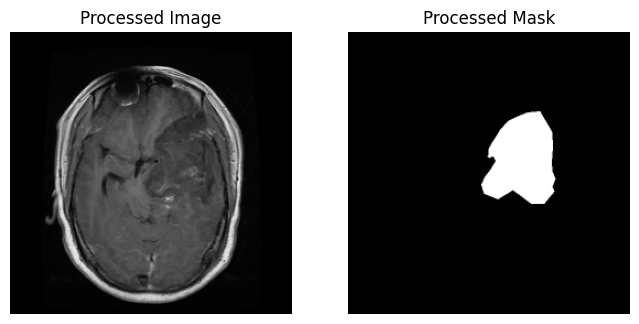

In [24]:
# Visualize one processed image and its mask

idx = 0  # index of image

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X[idx])
plt.title("Processed Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y[idx], cmap="gray")
plt.title("Processed Mask")
plt.axis("off")

plt.show()

In [25]:
# Save processed data for next steps

np.save("../data/X.npy", X)
np.save("../data/Y.npy", Y)

print("Data saved successfully!")

Data saved successfully!


In [26]:
# Define test data paths
test_base_path  = '../data/brisc2025/segmentation_task/test'
test_image_path = os.path.join(test_base_path, 'images')
test_mask_path  = os.path.join(test_base_path, 'masks')

print('Test Images path:', test_image_path)
print('Test Masks path: ', test_mask_path)
print('Test Images count:', len(os.listdir(test_image_path)))
print('Test Masks count: ', len(os.listdir(test_mask_path)))

Test Images path: ../data/brisc2025/segmentation_task/test\images
Test Masks path:  ../data/brisc2025/segmentation_task/test\masks
Test Images count: 860
Test Masks count:  860


In [27]:
# Load test images and masks, resize them exactly like train data
test_images = []
test_masks  = []

test_image_files = os.listdir(test_image_path)

for img_file in test_image_files:

    # Load image
    img = cv2.imread(os.path.join(test_image_path, img_file))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Load corresponding mask
    mask_file = img_file.replace('.jpg', '.png')
    mask = cv2.imread(os.path.join(test_mask_path, mask_file), 0)  # grayscale
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    test_images.append(img)
    test_masks.append(mask)

print('Loaded:', len(test_images), 'test images and', len(test_masks), 'test masks')

Loaded: 860 test images and 860 test masks


In [28]:
# Convert to numpy arrays
X_test = np.array(test_images)
Y_test = np.array(test_masks)

print('X_test shape:', X_test.shape)   # (N, 256, 256, 3)
print('Y_test shape:', Y_test.shape)   # (N, 256, 256)

X_test shape: (860, 256, 256, 3)
Y_test shape: (860, 256, 256)


In [29]:
# Normalize pixel values to [0, 1] — same as train data
X_test = X_test / 255.0
Y_test = Y_test / 255.0

print(' Test data normalized!')

 Test data normalized!


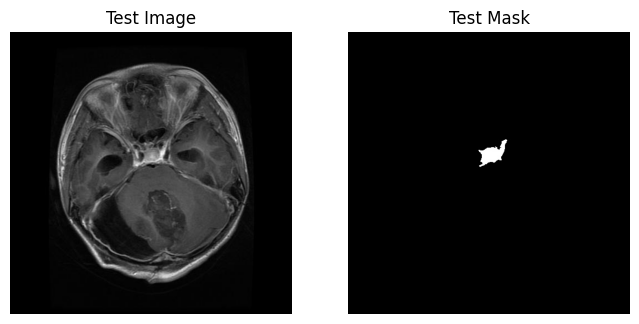

In [30]:
idx = 0

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
img = cv2.imread(os.path.join(test_image_path, test_image_files[idx]))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # open cv loads images in bgr format ,matplotlibe expects rgb so channels were swapped so i convert bgr to rgb
plt.imshow(img_rgb)
plt.title('Test Image')
plt.axis('off')

plt.subplot(1, 2, 2)
mask_file = test_image_files[idx].replace('.jpg', '.png')
mask = cv2.imread(os.path.join(test_mask_path, mask_file), 0)
plt.imshow(mask, cmap='gray')
plt.title('Test Mask')
plt.axis('off')

plt.show()

In [31]:
# Save test data
np.save('../data/X_test.npy', X_test)
np.save('../data/Y_test.npy', Y_test)

print(' Test data saved!')
print('   X_test → ../data/X_test.npy')
print('   Y_test → ../data/Y_test.npy')

 Test data saved!
   X_test → ../data/X_test.npy
   Y_test → ../data/Y_test.npy
